# Optical Water Types (OWT) retrieval

This tutorial shows how to classify every water pixel of a GRS Level-2A image into
**Optical Water Types** (OWT) with GRSl2bgen. An OWT groups waters with similar
reflectance spectra, and therefore similar optical constituents (phytoplankton,
sediments, CDOM). The OWT map is used later to select the most suitable retrieval
algorithms, see the {doc}`grsl2bgen_owt_blending` tutorial.

You will:

1. open a GRS L2A product and look at its content;
2. classify the image against the 13 inland-water OWT of Spyrakos et al. (2018);
3. repeat the classification with the 10 OWT of Bi and Hieronymi (2024);
4. compute the area covered by each OWT and inspect the corresponding spectra.

The mathematical description of the classification is given in {doc}`../algorithms`.

In [1]:


import os
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import xarray as xr
import rioxarray as rio
import pandas as pd
import datetime as dt
import cartopy.crs as ccrs

import GRSl2bgen

opj = os.path.join

print(f'-GRSl2bgen: {GRSl2bgen.__version__}')

-GRSl2bgen: 1.0.0


## Set the input path

`l2a_path` points to a GRS L2A product produced by
[GRSprocessor](https://github.com/CNES/GRSprocessor). It can be a `.nc` file, a `.zarr`
store, or a directory containing `<name>.nc` and its `<name>_anc.nc` ancillary file.
Replace it with the path of your own image.

In [2]:

l2a_path ='/data/satellite/Sentinel-2/subset/L2A/ambracian/2024/07/06/S2B_MSIL2A_20240706T091559_N0510_R093_T34SDJ_20240706T101118'


## Open and check the input L2A image

{py:class}`GRSl2bgen.product.Product` loads the product lazily (with dask) as an
`xarray.Dataset`. The main variables are:

- `Rrs`: remote-sensing reflectance $R_{rs}(\lambda)$ in sr$^{-1}$, with dimensions
  `(wl, y, x)` (wavelength in nm);
- `BRDFg`: sunglint reflectance removed by GRS;
- `mask` and `flags`: pixel classification and quality flags (water pixels have
  `mask == 0`).

In [3]:
prod = GRSl2bgen.Product(l2a_path)
prod.raster

INFO:root:Load L2A from files
/home/harmel/Dropbox/Dropbox/work/git/satellite_app/GRSl2bgen/GRSl2bgen/product.py:106: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 1024. This could degrade performance. Instead, consider rechunking after loading.
  self.raster = xr.open_dataset(main_file, decode_coords='all', chunks=chunks)
/home/harmel/Dropbox/Dropbox/work/git/satellite_app/GRSl2bgen/GRSl2bgen/product.py:106: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 1024. This could degrade performance. Instead, consider rechunking after loading.
  self.raster = xr.open_dataset(main_file, decode_coords='all', chunks=chunks)


<xarray.Dataset> Size: 2GB
Dimensions:             (wl: 11, y: 3206, x: 4400)
Coordinates:
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    time                datetime64[ns] 8B ...
  * x                   (x) float64 35kB 4.728e+05 4.728e+05 ... 5.097e+05
  * y                   (y) float64 26kB 4.331e+06 4.331e+06 ... 4.299e+06
    central_wavelength  (wl) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    spatial_ref         int64 8B ...
Data variables:
    Rrs                 (wl, y, x) float64 1GB dask.array<chunksize=(11, 1024, 1024), meta=np.ndarray>
    BRDFg               (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    aot550              (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    wind                (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mask                (y, x) uint8 14MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    vza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    sza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    raa                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    flags               (y, x) int64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    dem                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/73)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/34SDJ...
    product_name:                        S2B_MSIL1C_20240706T091559_N0510_R09...
    product_filename:                    S2B_MSIL1C_20240706T091559_N0510_R09...
    ...                                  ...
    vis_swir_index_threshold:            0.0
    hcld_threshold:                      0.003
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/anaconda3/envs/py12/lib...
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    metadata_profile:                    datacube

Get the map projection (UTM zone), pixel size and acquisition date, used for the
figures and for area computations below.

In [4]:
raster = prod.raster
crs = raster.rio.crs
str_epsg = str(crs)
zone = str_epsg[-2:]
is_south = str_epsg[2] == 7
proj = ccrs.UTM(zone, is_south)
x_res, y_res = raster.rio.resolution()
pixel_area = np.abs(x_res*y_res)
date = str(raster.time.dt.strftime('%Y/%m/%d').values)

Quick look at the image: true-colour composite built from $R_{rs}$ (left) and sunglint
reflectance estimated by GRS (right).

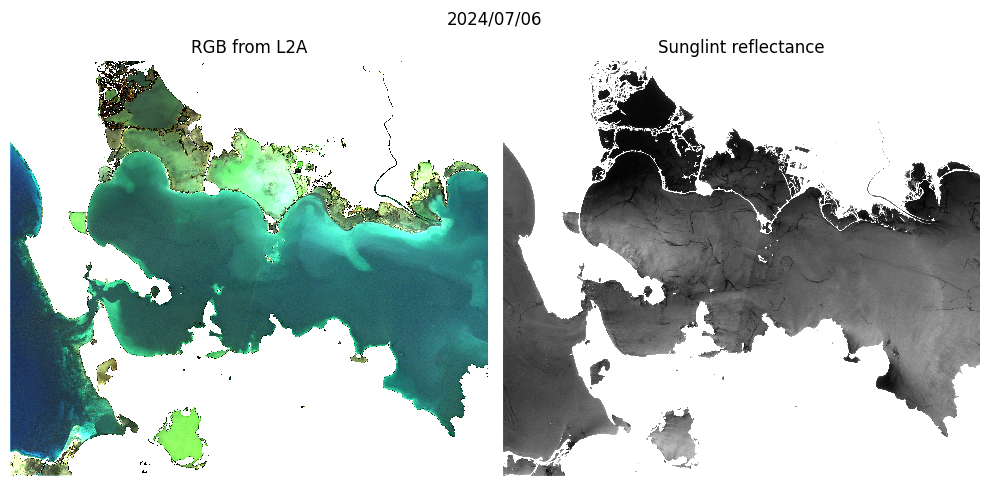

In [5]:


nrows=1
ncols=2
alpha=0.3
l2a_rgb = raster.Rrs.sel(wl= [670,565,490],method='nearest' )
fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5.,5*nrows),subplot_kw={'projection': proj}) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.05, wspace=0.07,)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]   

ax=axs[0]


bcmap = mpl.colors.ListedColormap([(0,0,0,0),'green','blue'])
# omni_mask.plot.imshow(cmap=bcmap,alpha=alpha,add_colorbar=False,ax=ax)
l2a_rgb.plot.imshow(rgb='wl', robust=True,ax=ax)
raster['BRDFg'].plot.imshow(cmap=plt.cm.gray, robust=True,vmin=0,vmax=0.04,ax=axs[1],add_colorbar=False)
 

ax.set_title("RGB from L2A")
axs[1].set_title("Sunglint reflectance")

#cbar_ax = fig.add_axes([0.3, 0.0, 0.4, 0.02])  # Left, bottom, width, height.
#cbar = fig.colorbar(im, cax=cbar_ax, extend='both', orientation='horizontal')
#cbar.set_label('$SPM\ (mg\cdot L^{-1})$')
plt.suptitle(date)
plt.tight_layout()


## OWT classification with Spyrakos et al. (2018)

The database of [Spyrakos et al. (2018)](https://aslopubs.onlinelibrary.wiley.com/doi/10.1002/lno.10674)
contains the mean spectra of 13 OWT found in inland and coastal waters. Each pixel
spectrum $\mathbf{R}$ is compared with every mean spectrum $\mathbf{R}_j$ with the
**Spectral Angle Mapper** (SAM):

$$
\theta_j = \arccos\left(\frac{\mathbf{R}\cdot\mathbf{R}_j}{\lVert\mathbf{R}\rVert\,\lVert\mathbf{R}_j\rVert}\right)
$$

computed over 350--800 nm. The smaller the angle $\theta_j$, the closer the spectral
*shapes*; the angle does not depend on the brightness of the pixel, which is why the
standardised spectra of the database can be used directly. The pixel is assigned to
the class with the smallest angle.

{py:class}`GRSl2bgen.owt.OWT` prepares the classification. By default only the best class
is kept (`Nclasses_to_be_saved=1`); use `spectral_distance='euclidean'` to use the
Euclidean distance instead of the SAM.

In [6]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Spyrakos2018')


Mean spectra of the 13 OWT (standardised $R_{rs}$, i.e. divided by their integral over
wavelength):

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='$Wavelength\\ (nm)$', ylabel='$Standardized\\ R_{rs}\\ (nm^{-1})$'>)

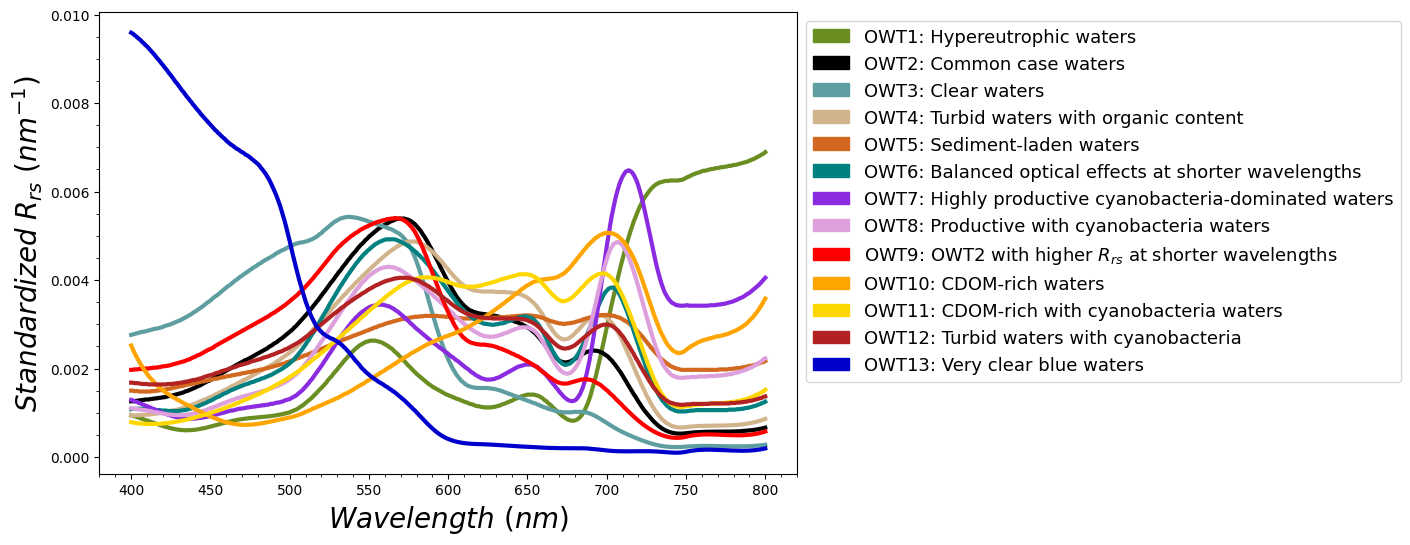

In [7]:
OWT.plot()

Run the classification. With dask-backed input the computation is lazy: it is
performed chunk by chunk when the result is plotted or written. The result is an
`xarray.Dataset` with:

- `owt_index`: class number (1 to 13) of the best-matching OWT;
- `owt_dist`: corresponding spectral angle (radians).

In [8]:
xowt_prod = OWT.multi_process()

INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product


Map of the OWT (left) and of the spectral angle to the selected class (right). Large
angles flag pixels that are poorly represented by the database (e.g. residual glint,
adjacency effects, or optically shallow waters).

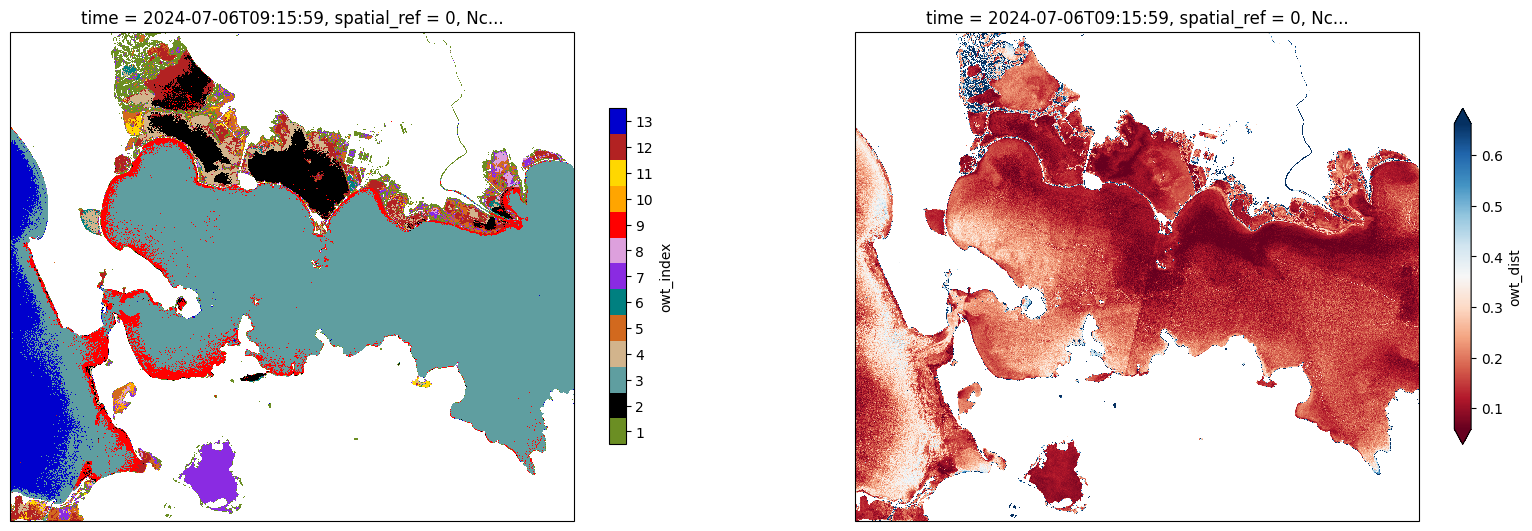

In [9]:
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)

cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
xowt_prod.owt_dist.plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64})

## Another database: Bi and Hieronymi (2024)

The [Bi and Hieronymi (2024)](https://aslopubs.onlinelibrary.wiley.com/doi/full/10.1002/lno.12606)
classification covers ocean, coastal and inland waters with 10 OWT, from extremely
clear blue waters (type 1) to CDOM-dominated dark waters (type 7). The same SAM
classification is applied: only the reference spectra change.

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='$Wavelength\\ (nm)$', ylabel='$Standardized\\ R_{rs}\\ (nm^{-1})$'>)

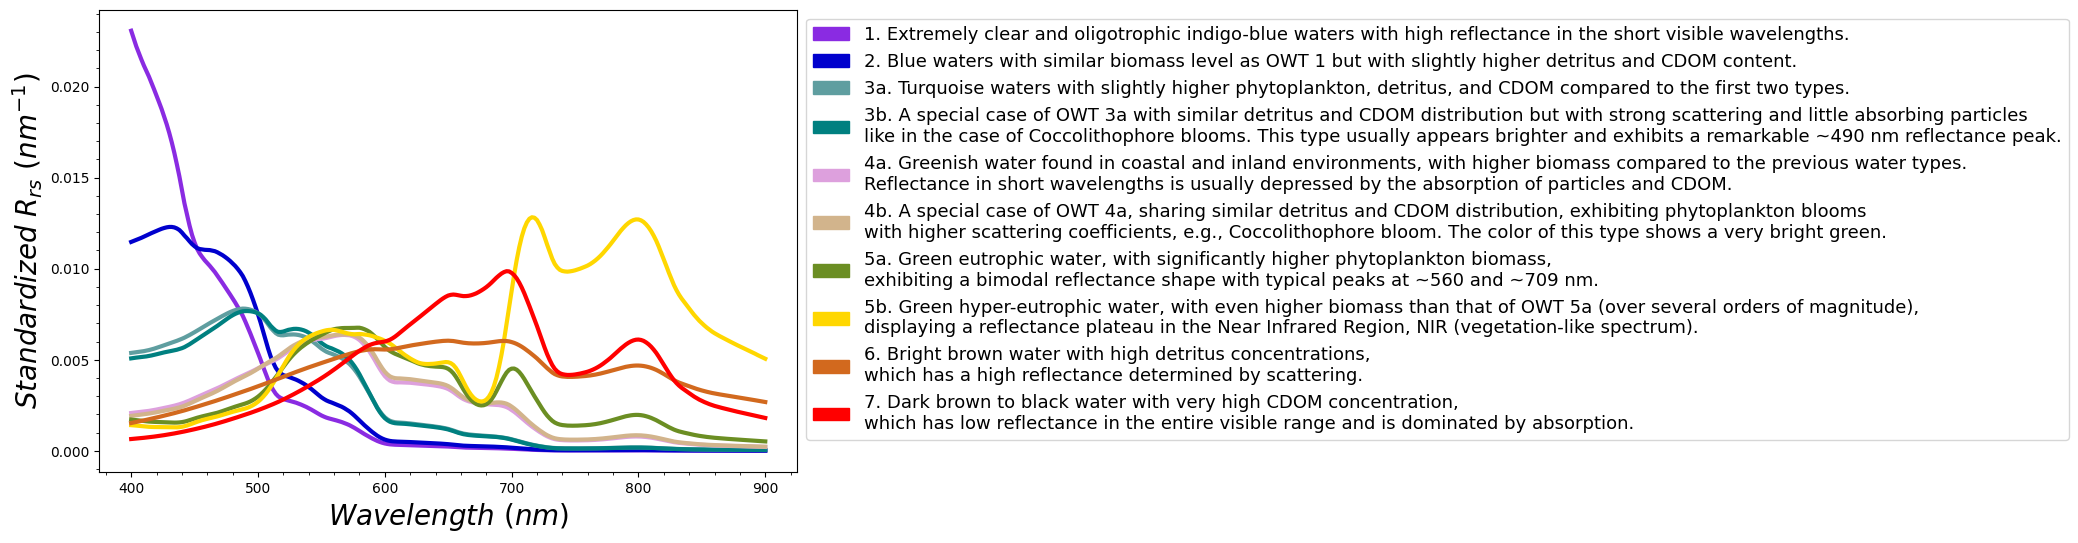

In [10]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Bi2024')

OWT.plot()

Classify the image and map the result (left) with the spectral angle (right):

In [11]:
xowt_prod = OWT.multi_process()

INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product


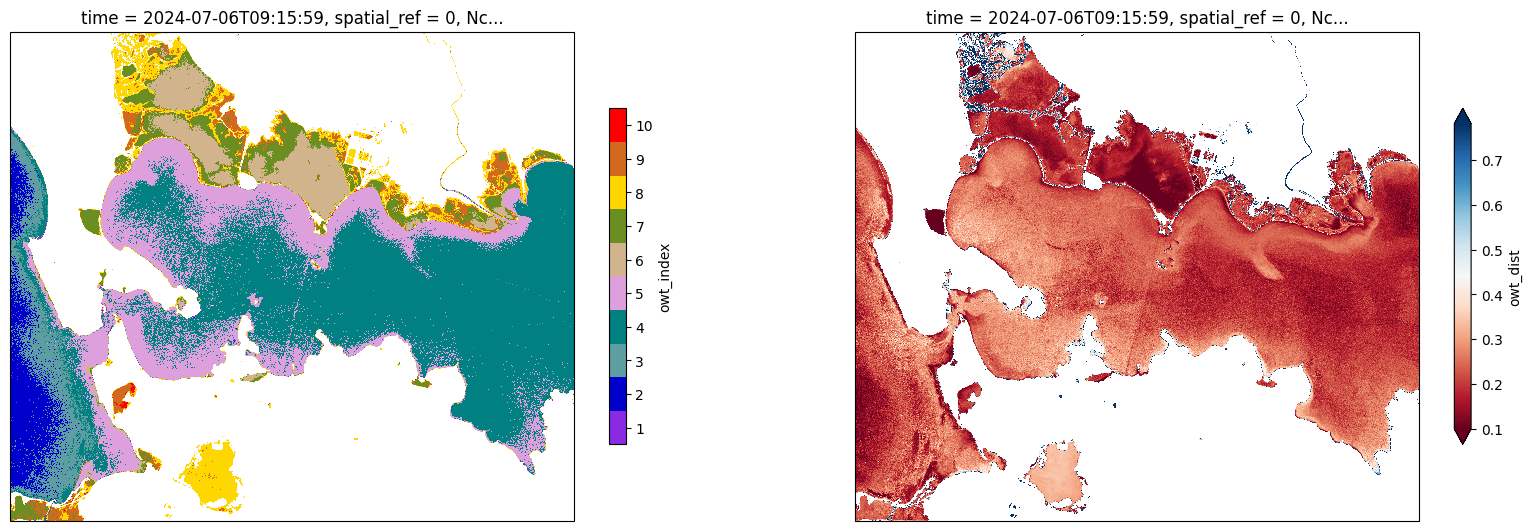

In [12]:
fig = plt.figure(figsize=(20, 15))
OWT.owt['owt']=['1','2','3a','3b','4a','4b','5a','5b','6','7']
ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)

cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
xowt_prod.owt_dist.plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64})

## Area and spectra of each OWT

Finally, count the pixels assigned to each OWT to get the area it covers
(number of pixels $\times$ pixel area), and plot the $R_{rs}$ spectra of each group to
check that the classification is consistent.

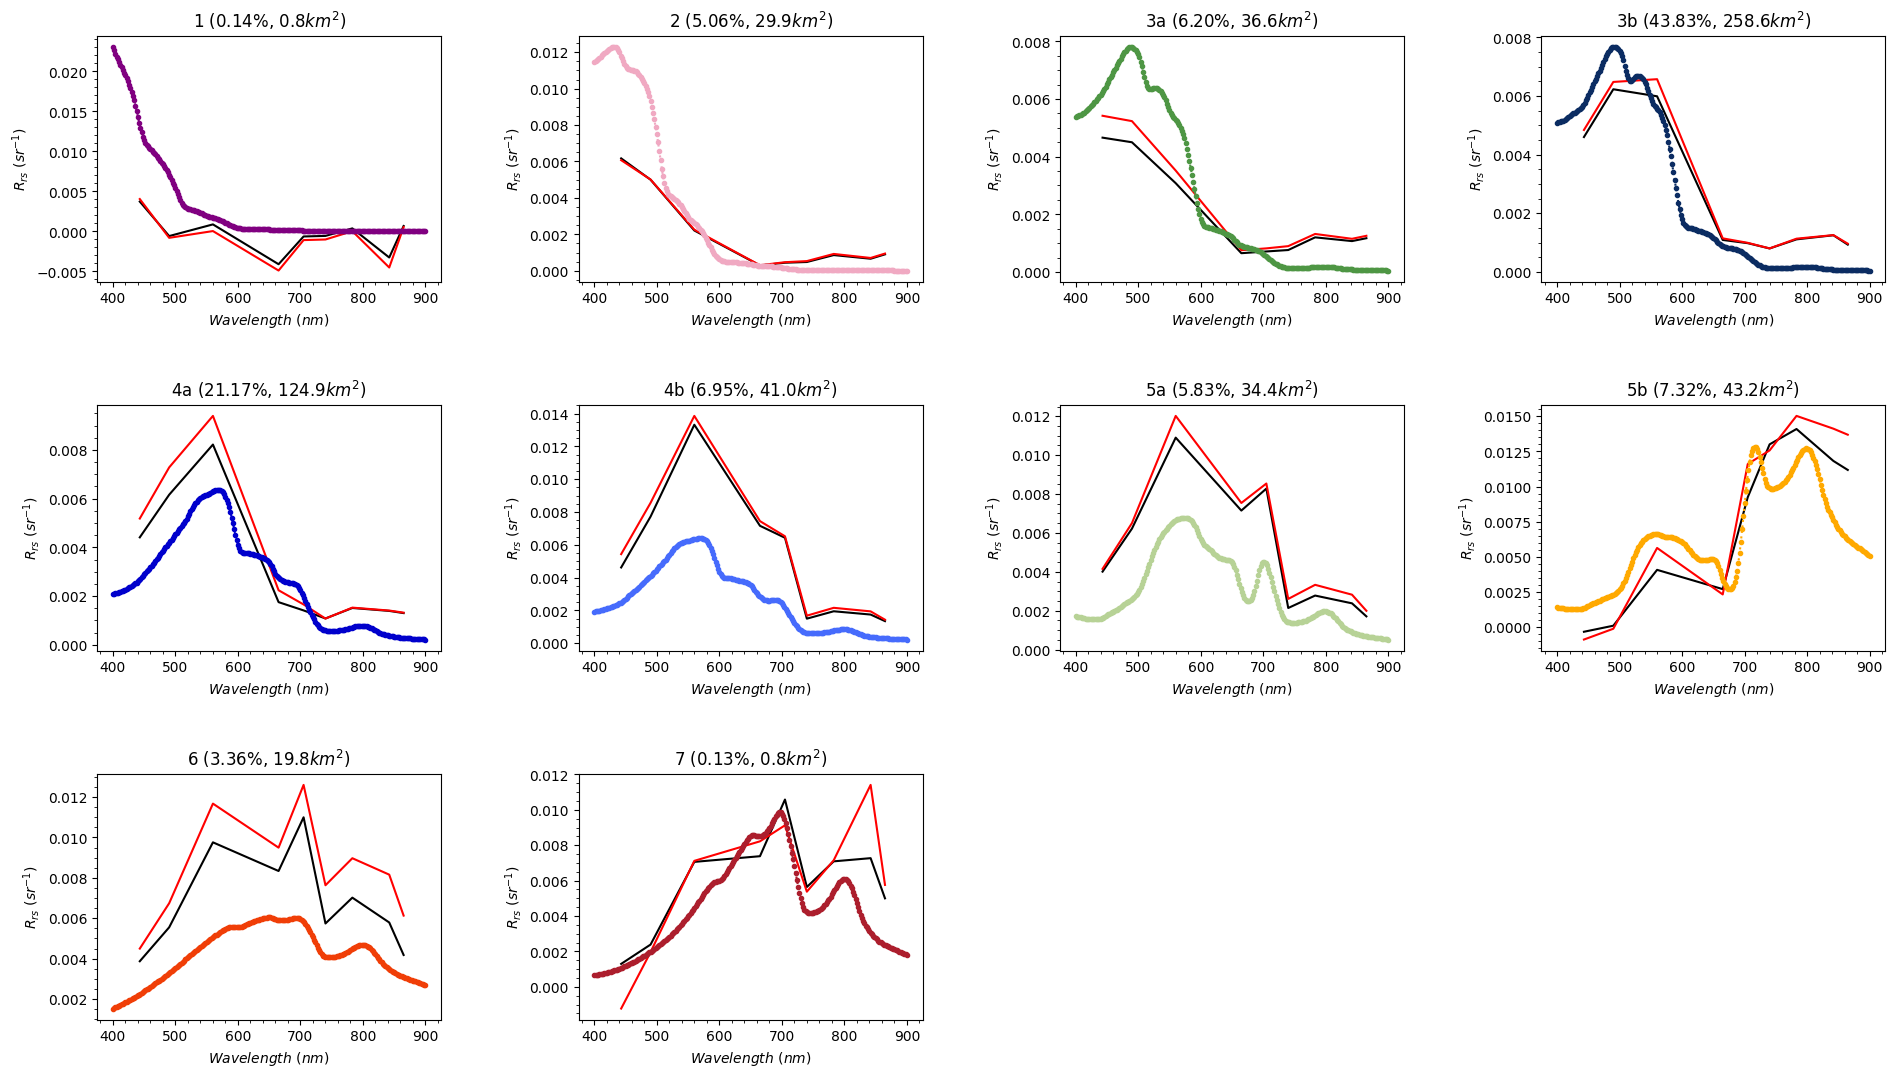

In [13]:
Nowt = OWT.Nowt
owt_roi = np.unique(xowt_prod.owt_index)
owt_roi = owt_roi[~np.isnan(owt_roi)].astype(int)
owt_roi

cmap_ = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['purple','pink',
                                                        'forestgreen',#'yellowgreen',
                                                      'navy', "blue", 'lightskyblue',"gold",
                                                     'orangered', "firebrick", 'purple'])
cmap.resampled(Nowt)
color_list = cmap_(np.linspace(0, 1, Nowt, 0))
cmap = cmap_.from_list('',color_list, Nowt)


ncols=4
Nowt_roi = len(owt_roi)
ncols=np.min([ncols,Nowt_roi])
nrows=int(np.ceil(Nowt_roi/ncols))    


norm = mpl.colors.Normalize(vmin=0.5, vmax=Nowt+0.5)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5,4*nrows)) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.5, wspace=0.4)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]
Rrs_raster = raster.Rrs.sel(wl=slice(400,1000))
Ntot = Rrs_raster.isel(wl=1).count()
for ii,owt_ in enumerate(owt_roi):
    ax=axs[ii]
    ax.set_axis_on()
    ax.minorticks_on()

    Rrs_roi = Rrs_raster.where(xowt_prod.owt_index==owt_)
    Npix = Rrs_roi.isel(wl=1).count()
    area = Npix*pixel_area*1e-6
    Rrs_roi.median(['x','y']).plot(c='k',label='median',ax=ax)
    Rrs_roi.mean(['x','y']).plot(c='r',label='mean',ax=ax)
    #ax.fill_between(wl, stats['isRrs_q25'], stats['isRrs_q75'],alpha=0.3,color='grey')
    #ax.fill_between(wl, stats['isRrs_min'], stats['isRrs_max'],alpha=0.1,color='grey')
    OWT.owt.isel(owt=owt_-1).plot(c=cmap(norm(owt_)),marker='o',ms=3,ls=':',label='OWT',ax=ax)
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})$')
    ax.set_title(str(OWT.owt.owt.values[owt_-1])+f' ({(Npix/Ntot*100).values:.2f}%, {area.values:.1f}'+r'$km^2$)')

## Next steps

- Use the OWT to blend chlorophyll-a algorithms: {doc}`grsl2bgen_owt_blending`.
- Run the full processing chain (OWT, Chl-a, SPM, CDOM, transparency) on an image:
  see the examples in {doc}`../processing_chain`.